# Sudan Climate Data EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("../data/sudan.csv")
df["Country"] = "Sudan"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [3]:
df = df.replace(-999, np.nan)

In [4]:
df.duplicated().sum()

np.int64(0)

### Duplicate Analysis

- No rows with duplicates were found

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains 4,108 daily observations from 2015 to 2026.

Temperature:
- The average temperature (T2M) is approximately 28.8 degrees, with values ranging from 13.18 to 37.99.
- Maximum daily temperature is 45.96 degree, while minimum temperature is around 5.93 degree.
- This indicates a hot climate with high variability.

Precipitation:
- The average daily precipitation is 0.64 mm, and the maximum is 66.49 mm.
- The median (0.00 mm) is much lower than the mean, suggesting there are many dry days and few days with heavy rain.

Humidity:
- Average humidity is 31.3%, but it ranges from 4.69% to 87.16%, indicating very high variability and generally dry conditions.

Wind:
- Average wind speed is about 3.48 m/s, indicating moderate wind conditions.

Overall the dataset suggests that the region experiences very hot temperatures, generally dry conditions with occasional heavy rain, and highly variable humidity levels.

In [6]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

There are no rows with missing values

In [7]:
missing_percent = df.isna().mean() * 100
missing_percent
missing_percent[missing_percent > 5]

Series([], dtype: float64)

### Missing Value Analysis

- After replacing -999 with NaN, no missing values were found in any column.

- The percentage of missing values across all columns is 0%, meaning no more than 5% missing values.

- This suggests the dataset is complete, and no imputation or row removal is required.

In [8]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3)

rows_with_outliers = outliers.any(axis=1).sum()
rows_with_outliers

np.int64(84)

### Outlier Analysis

Using the Z-score method (|Z| > 3), 84 rows with outliers were found.

Descision: Outliers should be kept in the dataset because they are likely real events (heavy rainfall or unusually high/low temperature) and not errors.

### Missing Value Handling

No missing values were found in the dataset so applying forward-fill or dropping rows was unnecessary.

In [9]:
df.to_csv("../data/sudan_clean.csv", index=False)

In [10]:
monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp

Month
1     21.895699
2     23.963245
3     27.943172
4     31.222455
5     34.131672
6     34.671576
7     32.023783
8     29.007977
9     30.177667
10    30.942405
11    26.927000
12    23.128270
Name: T2M, dtype: float64

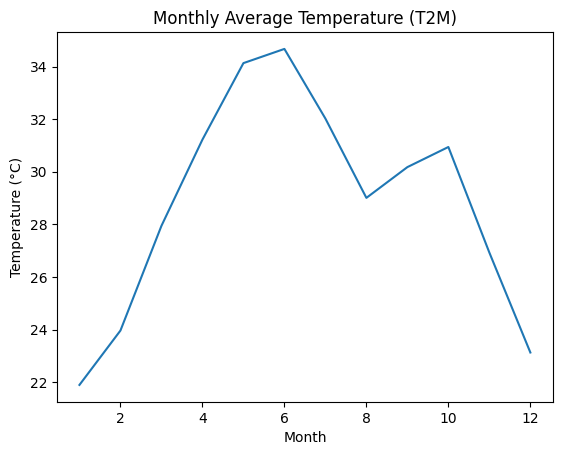

In [11]:
plt.figure()
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

In [12]:
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

warmest_month, coolest_month

(np.int32(6), np.int32(1))

### Monthly Temperature Trend

The temperature shows a clear seasonal pattern with strong variation across the year rather than a stable climate. The warmest period occurs in month 6, while the coolest occurs in month 1. There are no obvious anomalies.

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()
monthly_rain

Month
1        0.32
2        0.13
3        0.07
4        3.57
5      115.23
6      101.03
7      774.21
8     1152.10
9      378.93
10     109.86
11       3.18
12       6.41
Name: PRECTOTCORR, dtype: float64

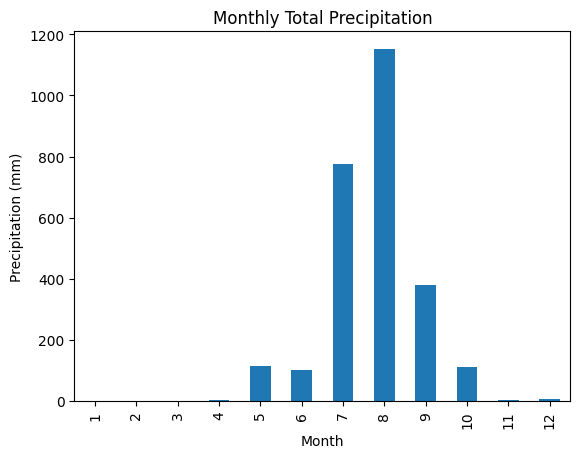

In [14]:
plt.figure()
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

In [15]:
monthly_rain.sort_values(ascending=False).head(3)

Month
8    1152.10
7     774.21
9     378.93
Name: PRECTOTCORR, dtype: float64

### Monthly Precipitation Analysis

The peak rainy months are July, August and September. There is strong seasonal variation in rainfall.

In [16]:
numeric_df = df[[
    "T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE",
    "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"
]]

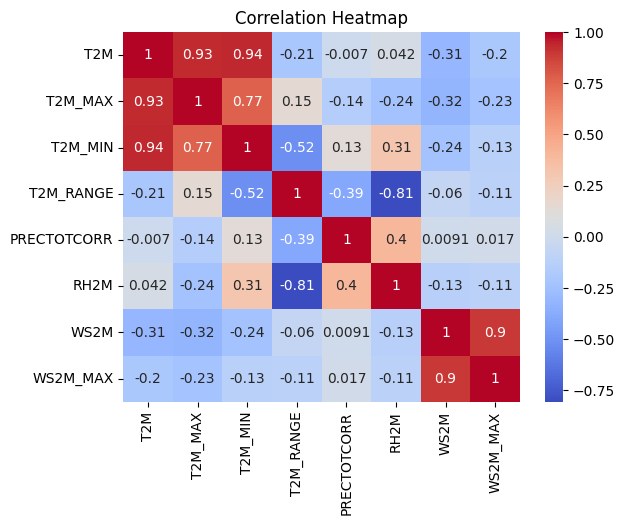

In [17]:
plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

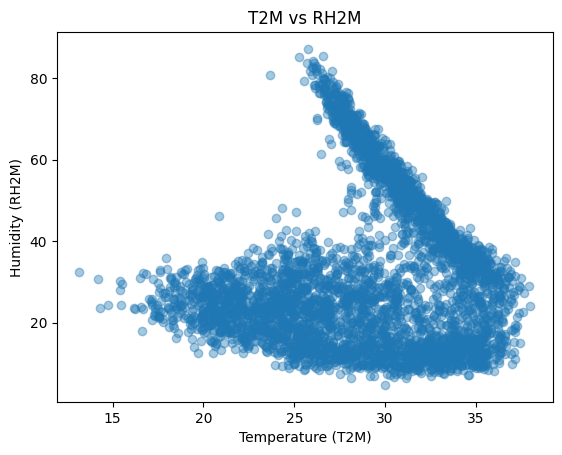

In [18]:
plt.figure()
plt.scatter(df["T2M"], df["RH2M"], alpha=0.4)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

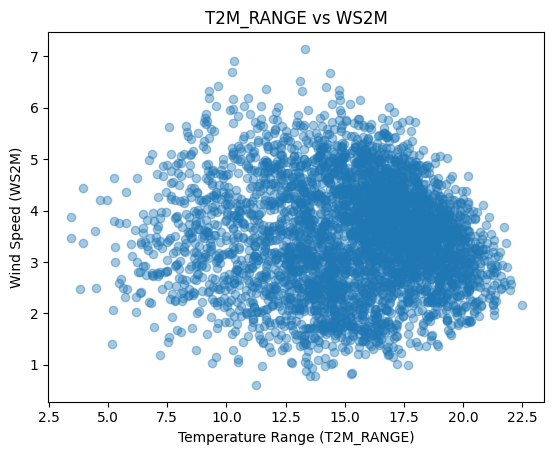

In [19]:
plt.figure()
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.4)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.show()

In [20]:
corr = numeric_df.corr().abs()

top_3 = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(3)
)

top_3

T2M   T2M_MIN     0.941858
      T2M_MAX     0.934277
WS2M  WS2M_MAX    0.900495
dtype: float64

### Strongest Correlations

The three strongest correlations in the dataset are:

1. T2M and T2M_MIN (0.941858)  
2. T2M and T2M_MAX (0.934277)  
3. WS2M and WS2M_MAX (0.900495)  

Interpretation:
- Average temperature (T2M) and minimum temperature (T2M_MIN) are very strongly correlated. This indicates that daily average temperatures closely follow nighttime or minimum temperature conditions.

- Average temperature (T2M) and maximum temperature (T2M_MAX) are also very strongly correlated. This suggests that hotter days consistently raise both average and peak temperatures.

- Daily average wind speed (WS2M) and maximum wind speed (WS2M_MAX) are strongly correlated, which is expected since they both measure wind intensity under different conditions.

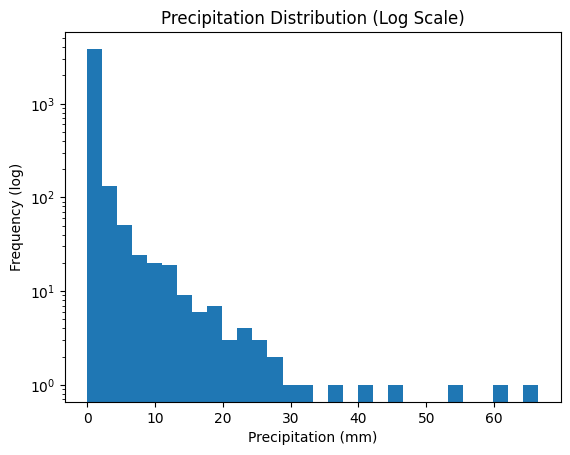

In [21]:
plt.figure()
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Precipitation Distribution (Log Scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency (log)")
plt.show()

### Precipitation Distribution

The distribution of daily precipitation is highly skewed, with most values clustered near zero and only a few extreme rainfall events.

This indicates that:
- Most days are dry or experience very low rainfall
- Heavy rainfall events occur occasionally


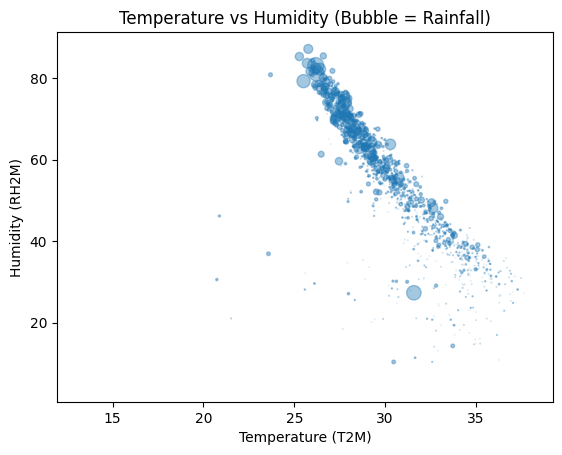

In [22]:
plt.figure()

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2,
    alpha=0.4
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Analysis

The bubble chart shows the relationship between temperature (T2M) and humidity (RH2M), with rainfall represented by bubble size.

Observations:
- The points form a slight downward pattern, indicating a weak negative relationship between temperature and humidity.
- Higher rainfall values (larger bubbles) are still clustered in a specific region rather than being evenly distributed.
- Rainfall appears more concentrated around moderate temperature and humidity conditions, rather than extreme values.